# Multiple Candidate Runs — How the Winner Gets Picked

There are 3 phases per bird: southbound, wintering, northbound. Each one needs to find its own best candidate. All 3 use the same selection process: find every candidate stretch, keep only the longest one, throw away the rest.

The only thing that differs between phases is what counts as "True" going in — southbound/northbound check rate of change (rising or falling), wintering checks distance from home (above 85% of the yearly max). Once that True/False signal exists, all 3 phases pick their winner the exact same way.

This notebook shows that selection process once, with one made-up example. Self-contained — no repo imports needed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def _longest_run_instrumented(mask, max_gap=0, within=None, max_total_gap=None):
    """
    Same logic as the real _longest_run() in segmentation.py, but this
    version also records EVERY candidate run it finds along the way,
    not just the final winner -- purely for this demonstration.
    """
    if max_total_gap is None:
        max_total_gap = max_gap
    lo, hi = within if within is not None else (0, len(mask) - 1)
    candidates = []  # every candidate run found, in order
    best = None
    run_start = None
    gap = 0
    total_gap = 0
    for i in range(lo, hi + 1):
        val = mask.iloc[i]
        if val:
            if run_start is None:
                run_start = i
                total_gap = 0
            gap = 0
        else:
            if run_start is not None:
                gap += 1
                total_gap += 1
                if gap > max_gap or total_gap > max_total_gap:
                    end = i - gap
                    candidates.append((run_start, end))
                    if best is None or (end - run_start) > (best[1] - best[0]):
                        best = (run_start, end)
                    run_start = None
                    gap = 0
                    total_gap = 0
    if run_start is not None:
        end = hi - gap
        candidates.append((run_start, end))
        if best is None or (end - run_start) > (best[1] - best[0]):
            best = (run_start, end)
    return best, candidates

## The example: 3 genuinely separate runs

29 fake days. We're using `max_gap = 2` and `max_total_gap = 2` — meaning any single gap longer than 2 days cannot be bridged.

This time the gaps between runs are long enough that they **cannot** be bridged (both exceed `max_gap = 2`), so we get 3 fully separate candidates instead of one chained-together run.

- **Candidate 1:** days 1–6 (length 6)
- **Gap:** days 7–11 (length 5 — exceeds `max_gap = 2`, too long to bridge)
- **Candidate 2:** days 12–21 (length 10)
- **Gap:** days 22–25 (length 4 — exceeds `max_gap = 2`, too long to bridge)
- **Candidate 3:** days 26–29 (length 4)

In [3]:
days = list(range(1, 30))
values = (
    [True] * 6      # days 1-6:   candidate 1
    + [False] * 5   # days 7-11:  gap, too long to bridge
    + [True] * 10   # days 12-21: candidate 2
    + [False] * 4   # days 22-25: gap, too long to bridge
    + [True] * 4    # days 26-29: candidate 3
)
mask = pd.Series(values)

assert len(values) == len(days)

In [4]:
# max_gap=2 means neither the 5-day gap nor the 4-day gap can be bridged
best, candidates = _longest_run_instrumented(mask, max_gap=2, max_total_gap=2)

print("All candidates found while scanning:")
for idx, (s, e) in enumerate(candidates, start=1):
    length = e - s + 1
    print(f"  Candidate {idx}: Day {days[s]} to Day {days[e]}  (length {length})")

print()
s, e = best
print(f"WINNER (only this one gets kept): Day {days[s]} to Day {days[e]}  (length {e - s + 1})")

All candidates found while scanning:
  Candidate 1: Day 1 to Day 6  (length 6)
  Candidate 2: Day 12 to Day 21  (length 10)
  Candidate 3: Day 26 to Day 29  (length 4)

WINNER (only this one gets kept): Day 12 to Day 21  (length 10)


You should see all 3 candidates printed, and Candidate 2 (days 12–21, length 10) declared the winner — the other two are found, printed here for demonstration, but would normally be silently discarded by the real code.

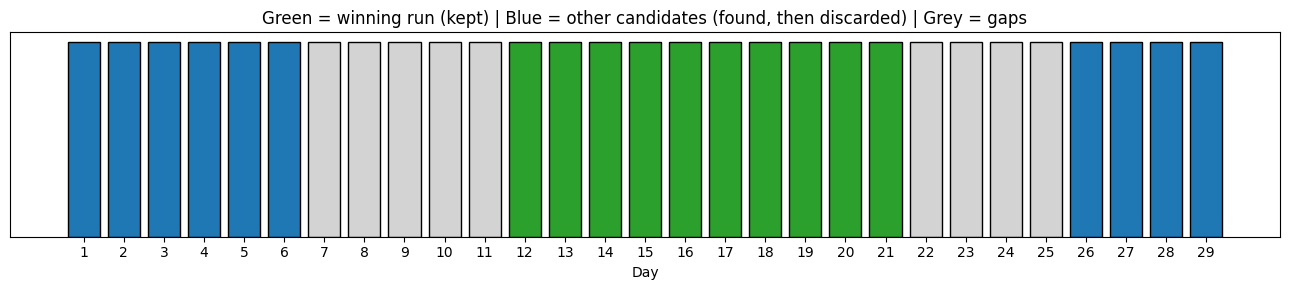

In [5]:
# Visualize: every candidate in blue, the winner highlighted in green
colors = []
for i, v in enumerate(values):
    if best[0] <= i <= best[1]:
        colors.append("tab:green")
    elif v:
        colors.append("tab:blue")
    else:
        colors.append("lightgrey")

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(days, [1] * len(days), color=colors, edgecolor="black")
ax.set_xticks(days)
ax.set_yticks([])
ax.set_xlabel("Day")
ax.set_title("Green = winning run (kept) | Blue = other candidates (found, then discarded) | Grey = gaps")
plt.tight_layout()
plt.show()

## Important note: What these 3 fake candidates represent

These 3 candidates are **not** one for southbound, one for wintering, one for northbound. They're 3 competing candidates for **the same single phase** — imagine they're all candidates for southbound (or equally, all for wintering, or all for northbound; it doesn't matter which, since all 3 phases use this exact same selection process). One phase, 3 competing stretches, only 1 winner picked from among them.